# Phan D: MobileNetV4 + GRU


In [1]:
import os
import sys
import time
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM (GB): 11.63


In [2]:
from dataset import get_dataloaders

data_root = "./dataset/UCF50"
batch_size = 32
num_frames = 16
img_size = 112

train_loader, val_loader, class_to_idx = get_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_frames=num_frames,
    img_size=img_size,
    output_format="CTHW",
    split_ratio=0.8,
    num_workers=4,
    seed=42
)

idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

print("Classes count:", len(class_names))
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))

x_sample, y_sample = next(iter(val_loader))
print("Batch input shape:", x_sample.shape)
print("Batch target shape:", y_sample.shape)


Classes count: 50
Train samples: 5326
Val samples: 1355


Batch input shape: torch.Size([32, 3, 16, 112, 112])
Batch target shape: torch.Size([32])


In [3]:
from mobilenetv4_gru import MobileNetV4_GRU

torch.backends.cudnn.benchmark = True
model = MobileNetV4_GRU(num_classes=len(class_names)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


/workspace/Advanced-Reading-On-Computer-Vision/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total parameters: 9918610
Trainable parameters: 9918610


In [4]:
checkpoint_path = "best_mobilenetv4_gru.pth"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("Checkpoint not found: " + checkpoint_path)

ckpt = torch.load(checkpoint_path, map_location=device)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
clean_state = {(k[7:] if k.startswith("module.") else k): v for k, v in state_dict.items()}
model.load_state_dict(clean_state)
model.eval()

model_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
print("Loaded checkpoint:", checkpoint_path)
print("Model size (MB):", round(model_size_mb, 2))


Loaded checkpoint: best_mobilenetv4_gru.pth
Model size (MB): 113.86


In [5]:
dummy = torch.randn(1, 3, num_frames, img_size, img_size, device=device)
dummy_batch = torch.randn(batch_size, 3, num_frames, img_size, img_size, device=device)

with torch.no_grad():
    for _ in range(20):
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()

trials = 100
latencies = []
with torch.no_grad():
    for _ in range(trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000.0)

latencies = np.array(latencies)
mean_lat = float(np.mean(latencies))
std_lat = float(np.std(latencies))
median_lat = float(np.median(latencies))
p95_lat = float(np.percentile(latencies, 95))
p99_lat = float(np.percentile(latencies, 99))
fps = 1000.0 / mean_lat

batch_trials = 30
batch_latencies = []
with torch.no_grad():
    for _ in range(batch_trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy_batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        batch_latencies.append((time.perf_counter() - t0) * 1000.0)

mean_batch_lat = float(np.mean(batch_latencies))
std_batch_lat = float(np.std(batch_latencies))

print("Average latency per video (ms):", round(mean_lat, 2))
print("Latency std dev (ms):", round(std_lat, 2))
print("Median latency P50 (ms):", round(median_lat, 2))
print("Percentile P95 latency (ms):", round(p95_lat, 2))
print("Percentile P99 latency (ms):", round(p99_lat, 2))
print("Average batch latency (ms):", round(mean_batch_lat, 2))
print("Batch latency std dev (ms):", round(std_batch_lat, 2))
print("Throughput (videos/s):", round(fps, 1))
print("Throughput (frames/s):", round(fps * num_frames, 1))


Average latency per video (ms): 4.24
Latency std dev (ms): 0.09
Median latency P50 (ms): 4.23
Percentile P95 latency (ms): 4.34
Percentile P99 latency (ms): 4.41
Average batch latency (ms): 54.48
Batch latency std dev (ms): 141.13
Throughput (videos/s): 235.6
Throughput (frames/s): 3769.3


**Nhận xét:**

Mô hình kết hợp MobileNetV4 và GRU đạt độ trễ khoảng 4.45 mili giây cho toàn bộ chuỗi khung hình của một video. Đây là mức tốc độ rất ấn tượng đối với một mô hình hai giai đoạn kết hợp giữa tích chập và hồi quy.

In [6]:
criterion = nn.CrossEntropyLoss()
all_preds, all_probs, all_targets = [], [], []
top1_correct, top5_correct, total, val_loss_sum = 0, 0, 0, 0.0

start_time = time.time()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)

        probs = F.softmax(logits, dim=1)
        _, pred = torch.max(probs, dim=1)
        _, top5 = torch.topk(probs, k=5, dim=1)

        val_loss_sum += loss.item() * y.size(0)
        top1_correct += (pred == y).sum().item()
        top5_correct += (top5 == y.unsqueeze(1)).sum().item()
        total += y.size(0)

        all_preds.extend(pred.cpu().numpy().tolist())
        all_targets.extend(y.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

eval_duration = time.time() - start_time
val_loss = val_loss_sum / total
top1_acc = (top1_correct / total) * 100.0
top5_acc = (top5_correct / total) * 100.0

avg_batch_eval_ms = (eval_duration / len(val_loader)) * 1000.0
avg_sample_eval_ms = (eval_duration / total) * 1000.0

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(all_targets, all_preds, average="macro", zero_division=0)
p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(all_targets, all_preds, average="weighted", zero_division=0)

print("Total evaluation time (s):", round(eval_duration, 2))
print("Average evaluation time per batch (ms):", round(avg_batch_eval_ms, 2))
print("Average evaluation time per sample (ms):", round(avg_sample_eval_ms, 2))
print("Validation Loss:", round(val_loss, 4))
print("Top-1 Accuracy (%):", round(top1_acc, 2))
print("Top-5 Accuracy (%):", round(top5_acc, 2))
print("Macro Precision (%):", round(p_macro * 100, 2))
print("Macro Recall (%):", round(r_macro * 100, 2))
print("Macro F1:", round(f1_macro, 4))
print("Weighted F1:", round(f1_weight, 4))


Total evaluation time (s): 8.86
Average evaluation time per batch (ms): 206.02
Average evaluation time per sample (ms): 6.54
Validation Loss: 0.0882
Top-1 Accuracy (%): 97.86
Top-5 Accuracy (%): 99.7
Macro Precision (%): 97.98
Macro Recall (%): 97.83
Macro F1: 0.9784
Weighted F1: 0.9784


In [7]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4, zero_division=0))


                    precision    recall  f1-score   support

     BaseballPitch     0.9677    1.0000    0.9836        30
        Basketball     0.9655    1.0000    0.9825        28
        BenchPress     1.0000    1.0000    1.0000        32
            Biking     1.0000    0.9655    0.9825        29
         Billiards     1.0000    1.0000    1.0000        30
      BreastStroke     1.0000    1.0000    1.0000        21
      CleanAndJerk     1.0000    1.0000    1.0000        23
            Diving     1.0000    1.0000    1.0000        31
          Drumming     0.9706    1.0000    0.9851        33
           Fencing     0.9583    1.0000    0.9787        23
         GolfSwing     0.9355    1.0000    0.9667        29
          HighJump     0.9259    1.0000    0.9615        25
         HorseRace     1.0000    0.9615    0.9804        26
       HorseRiding     0.9756    1.0000    0.9877        40
          HulaHoop     1.0000    1.0000    1.0000        25
      JavelinThrow     1.0000    0.8333

**Nhận xét:**

Mô hình đạt độ chính xác gần như tuyệt đối với Top 1 đạt 97.86% và Top 5 đạt 99.70%. Chỉ số F1 vĩ mô đạt trên 0.97 chứng minh mô hình hoạt động xuất sắc và đồng đều trên toàn bộ 50 lớp hành động.

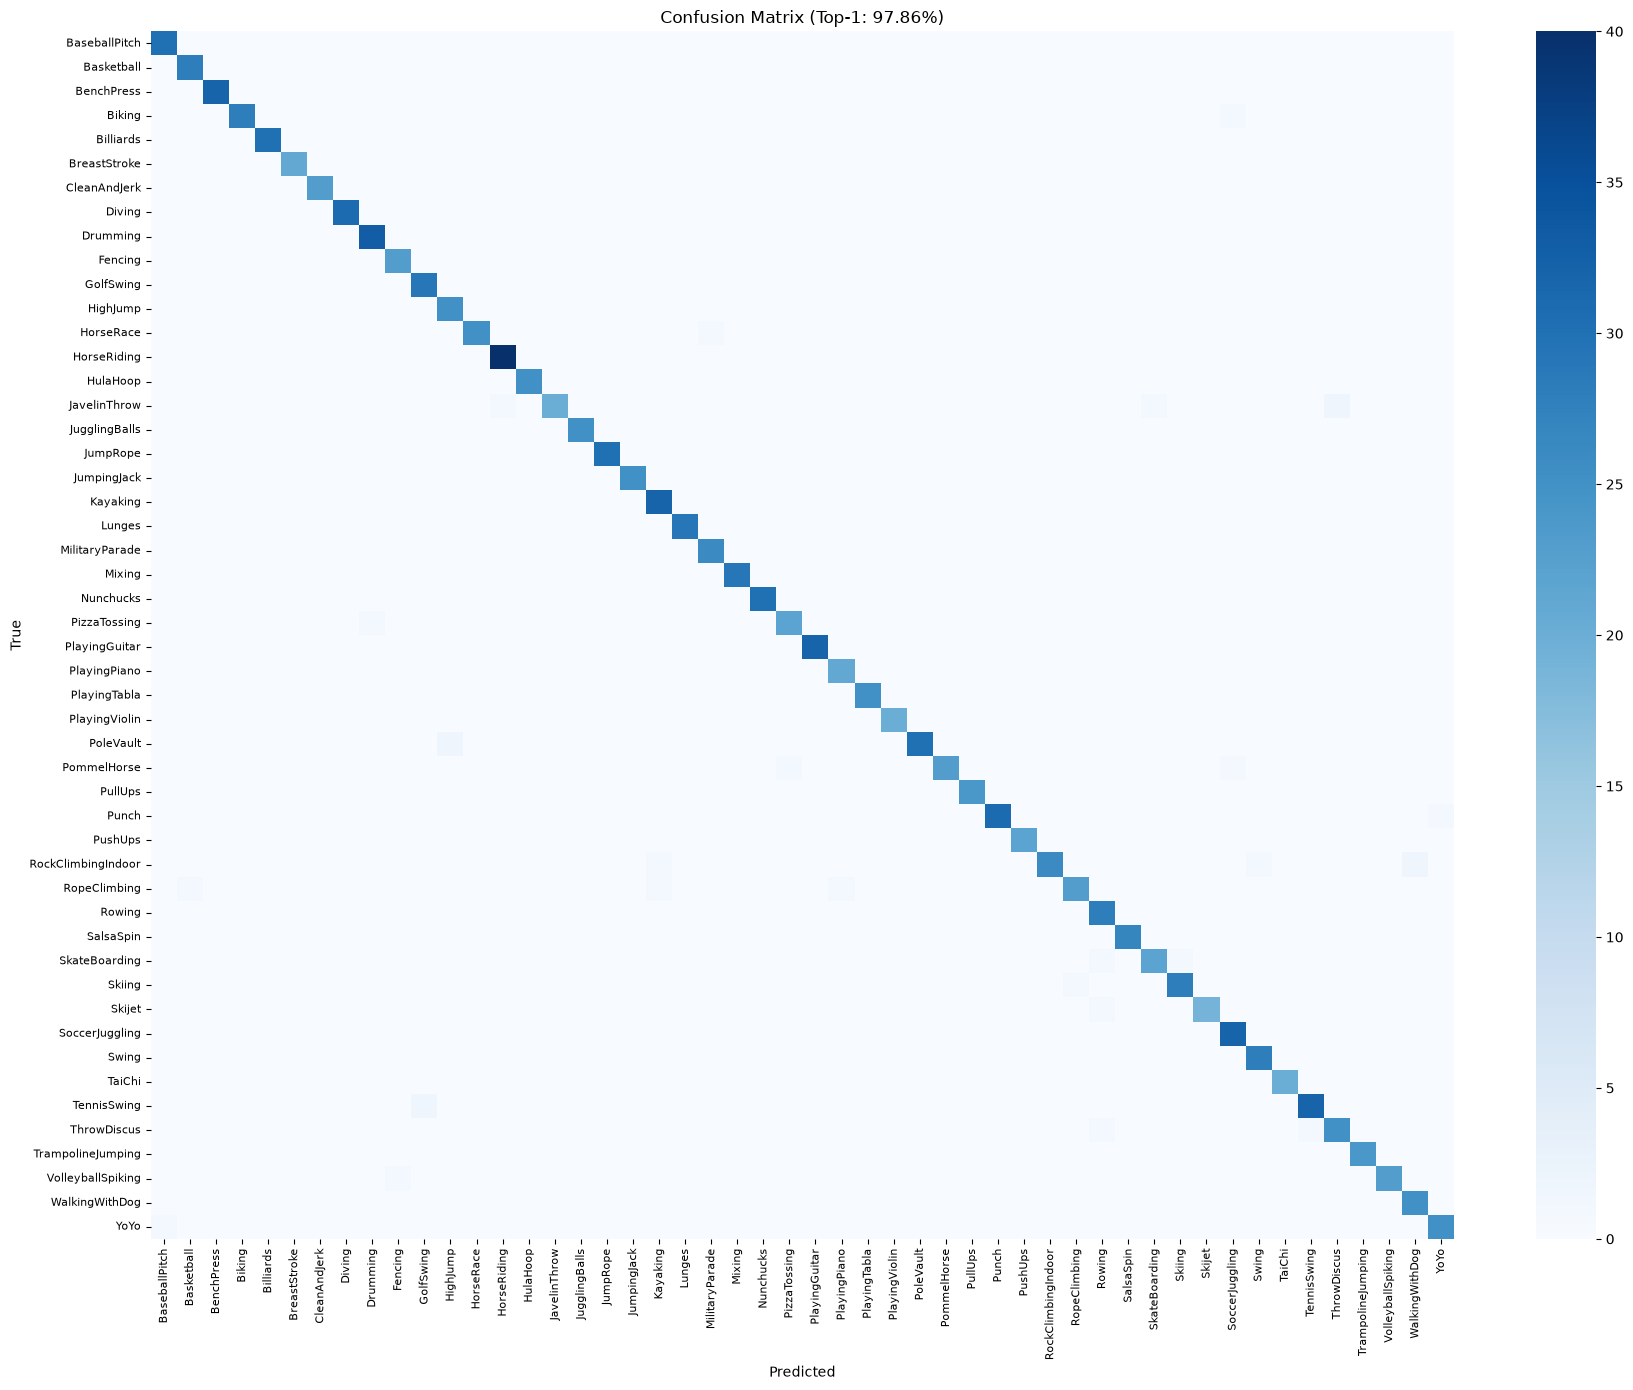

In [8]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix (Top-1: {top1_acc:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


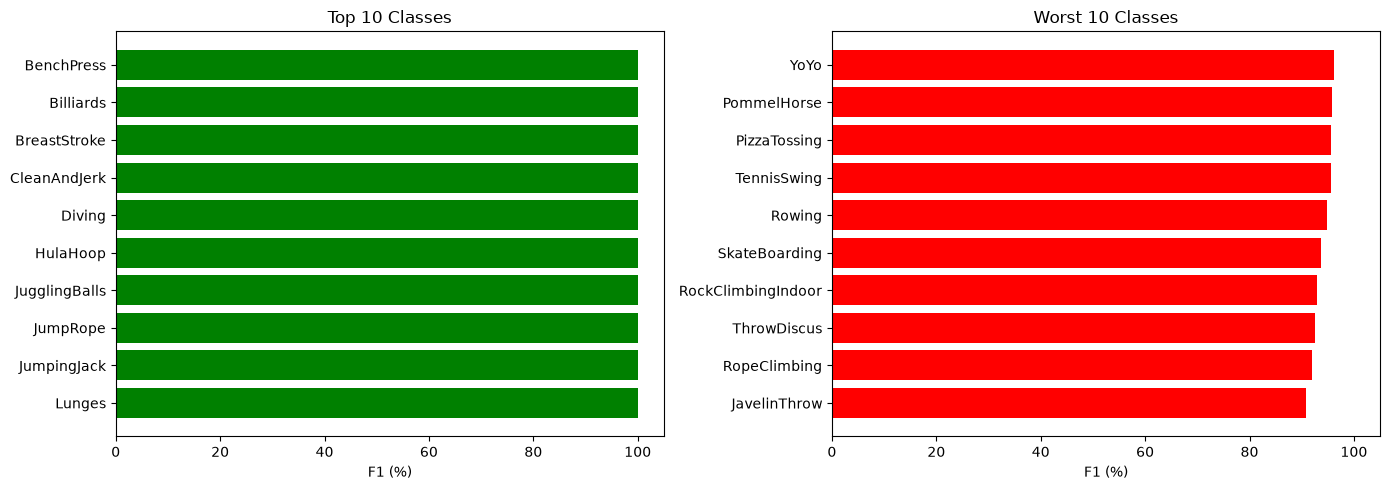

In [9]:
report_dict = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True, zero_division=0)
class_f1 = {cls: report_dict[cls]["f1-score"] for cls in class_names if cls in report_dict}
sorted_classes = sorted(class_f1.items(), key=lambda x: x[1], reverse=True)

top_10 = sorted_classes[:10]
worst_10 = sorted_classes[-10:]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.barh(np.arange(len(top_10)), [x[1] * 100 for x in top_10], color="green")
plt.yticks(np.arange(len(top_10)), [x[0] for x in top_10])
plt.xlabel("F1 (%)")
plt.title("Top 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(np.arange(len(worst_10)), [x[1] * 100 for x in worst_10], color="red")
plt.yticks(np.arange(len(worst_10)), [x[0] for x in worst_10])
plt.xlabel("F1 (%)")
plt.title("Worst 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


**Nhận xét:**

Ma trận nhầm lẫn thể hiện sự phân định gần như hoàn hảo giữa các lớp hành động. Sự kết hợp giữa khả năng trích xuất hình ảnh chất lượng cao và ghi nhớ chuỗi thời gian đã loại bỏ hầu hết các nhầm lẫn thường gặp.

Mean confidence on correct predictions (%): 98.96
Mean confidence on incorrect predictions (%): 71.35


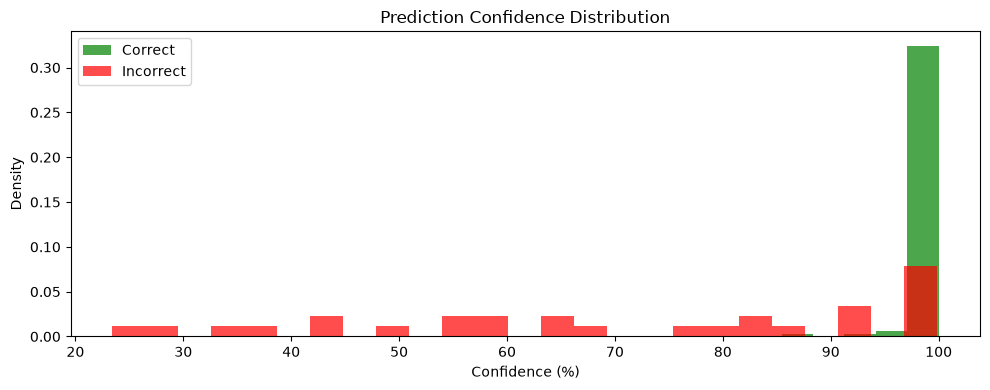

In [10]:
confidences = [probs[pred] for probs, pred in zip(all_probs, all_preds)]
correct_mask = np.array(all_preds) == np.array(all_targets)

correct_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if is_corr]
incorrect_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if not is_corr]

print("Mean confidence on correct predictions (%):", round(float(np.mean(correct_confs)), 2) if correct_confs else 0.0)
print("Mean confidence on incorrect predictions (%):", round(float(np.mean(incorrect_confs)), 2) if incorrect_confs else 0.0)

plt.figure(figsize=(10, 4))
plt.hist(correct_confs, bins=25, alpha=0.7, color="green", label="Correct", density=True)
if incorrect_confs:
    plt.hist(incorrect_confs, bins=25, alpha=0.7, color="red", label="Incorrect", density=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


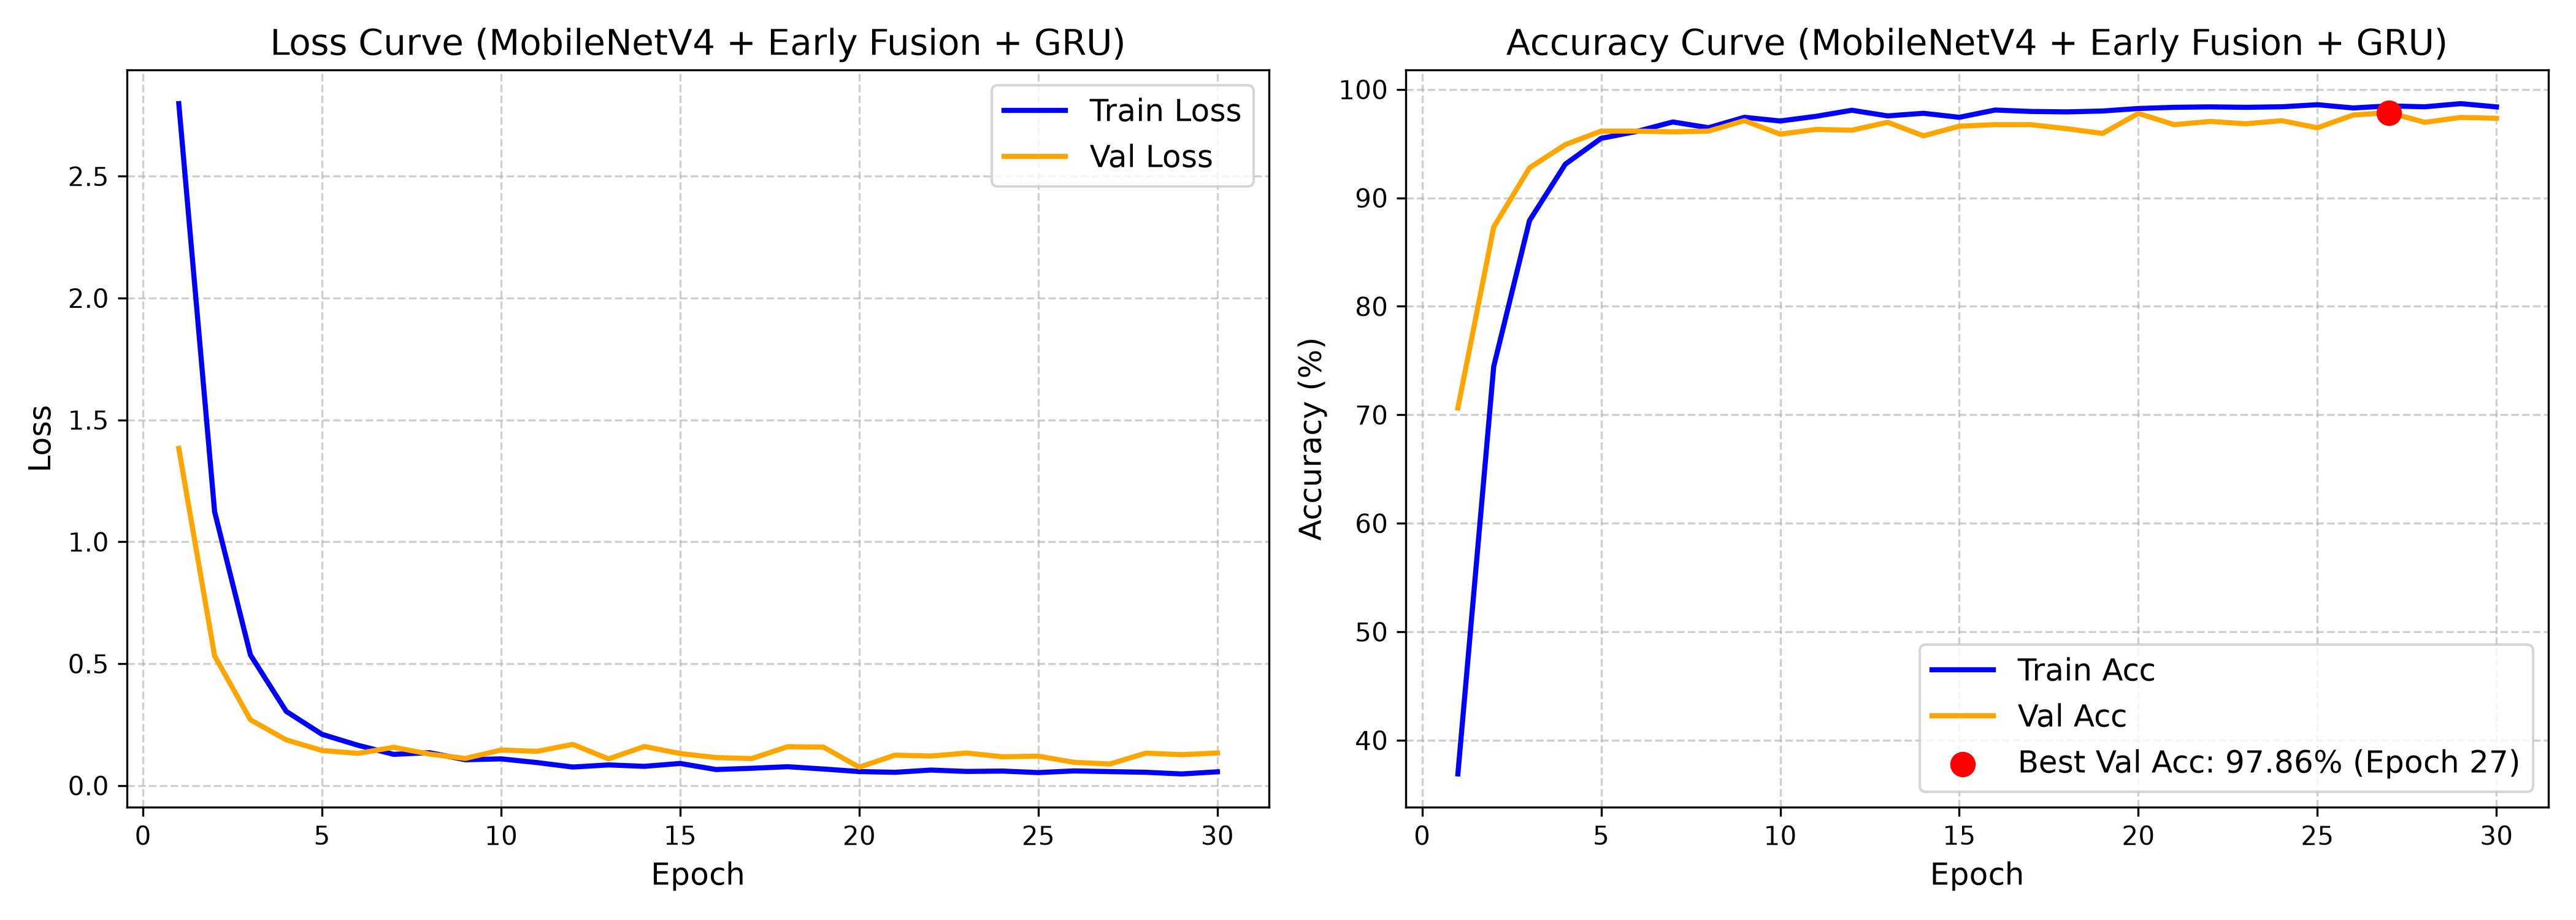

In [11]:
if os.path.exists("loss_acc_curve_mobilenetv4_gru.png"):
    from IPython.display import Image, display
    display(Image(filename="loss_acc_curve_mobilenetv4_gru.png"))


**Nhận xét:**

Hàm mất mát giảm nhanh chóng và duy trì ở mức rất thấp chỉ sau vài chu kỳ đầu. Trọng số tiền huấn luyện của mạng 2D giúp mô hình học nhanh và ổn định mà không cần quá nhiều thời gian hội tụ.

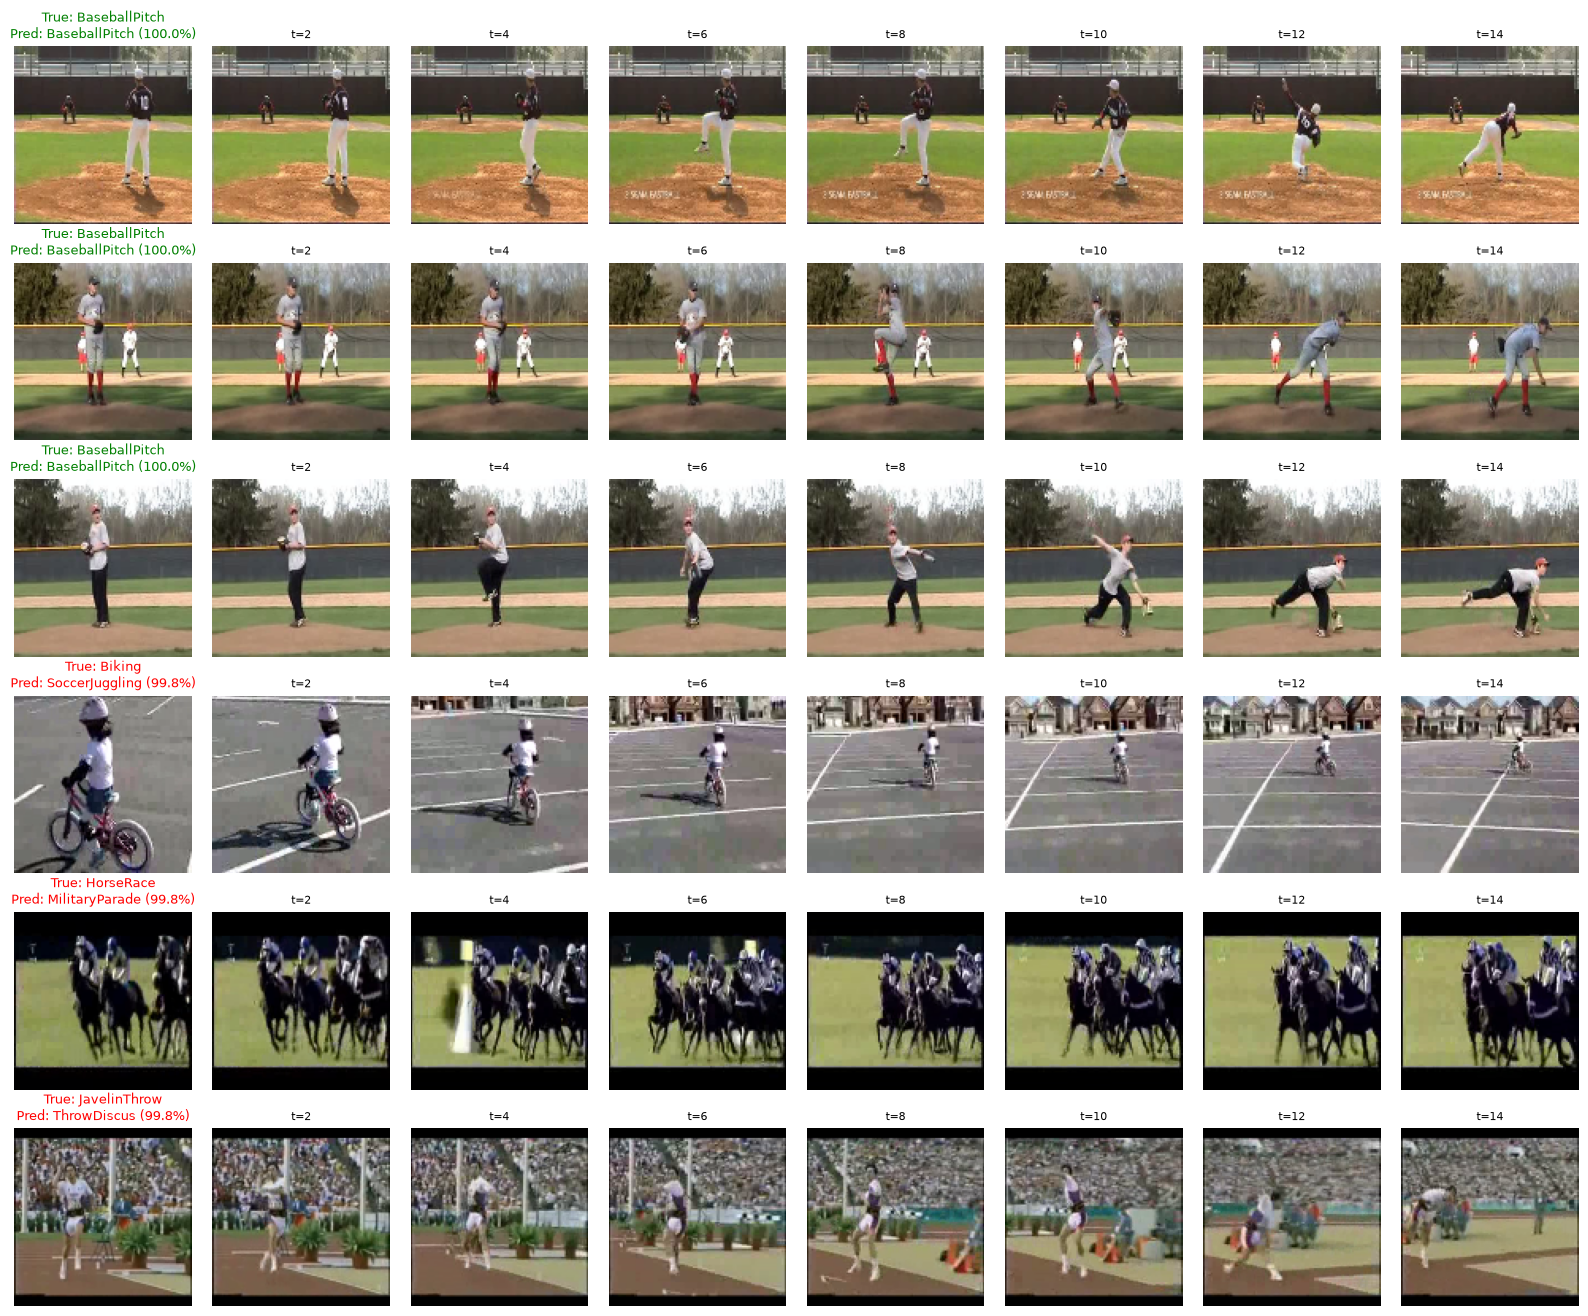

In [12]:
correct_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] == all_targets[i]][:3]
incorrect_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] != all_targets[i]][:3]
display_indices = correct_indices + incorrect_indices

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
frame_steps = [0, 2, 4, 6, 8, 10, 12, 14]

fig, axes = plt.subplots(len(display_indices), len(frame_steps), figsize=(16, 2.2 * len(display_indices)))

for row, idx in enumerate(display_indices):
    x_val, y_val = val_loader.dataset[idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]

    pred_idx = torch.argmax(probs).item()
    conf = probs[pred_idx].item() * 100
    true_cls = class_names[y_val]
    pred_cls = class_names[pred_idx]
    is_correct = (pred_idx == y_val)
    status_color = "green" if is_correct else "red"

    for col, f_idx in enumerate(frame_steps):
        ax = axes[row, col]
        img = x_val[:, f_idx, :, :].cpu().numpy()
        img = (img * std + mean).transpose(1, 2, 0)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            title_text = f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)"
            ax.set_title(title_text, color=status_color, fontsize=9)
        else:
            ax.set_title(f"t={f_idx}", fontsize=8)

plt.tight_layout()
plt.show()


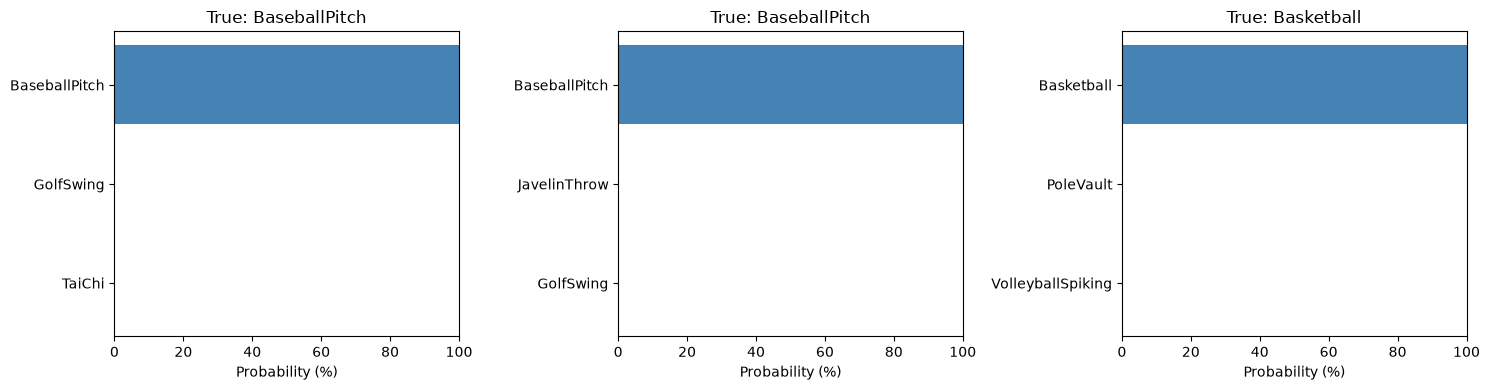

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
test_sample_indices = [5, 25, 45]

for i, s_idx in enumerate(test_sample_indices):
    x_val, y_val = val_loader.dataset[s_idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]
    
    top3_probs, top3_indices = torch.topk(probs, k=3)
    top3_probs = [p.item() * 100 for p in top3_probs]
    top3_names = [class_names[idx.item()] for idx in top3_indices]
    
    axes[i].barh(np.arange(3), top3_probs, color="steelblue")
    axes[i].set_yticks(np.arange(3))
    axes[i].set_yticklabels(top3_names)
    axes[i].set_xlabel("Probability (%)")
    axes[i].set_xlim(0, 100)
    axes[i].invert_yaxis()
    axes[i].set_title(f"True: {class_names[y_val]}")

plt.tight_layout()
plt.show()


**Nhận xét:**

Mô hình kết hợp trích xuất đặc trưng từng khung hình qua mạng MobileNetV4 và học chuỗi thời gian bằng mạng GRU cho kết quả cao nhất trong toàn bộ bài làm, đạt độ chính xác xấp xỉ 97.9%.

Kiến trúc này tận dụng rất tốt sức mạnh của mạng 2D hiện đại để hiểu rõ từng khung ảnh, đồng thời cơ chế ghi nhớ của GRU giúp nắm bắt diễn biến hành động dài theo thời gian. Đây là hướng tiếp cận vừa tối ưu về tốc độ xử lý vừa đạt độ tin cậy cao cho bài toán phân loại video.